# Jackpot 🎰
### "Avoid the lottery stocks" — sound advice that backfired on large caps

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Lottery effect on large caps?: Busted](https://img.shields.io/badge/Lottery_effect_on_large_caps%3F-Busted-8b949e?style=flat-square)

Behavioural finance says investors overpay for stocks with recent jackpot-like daily gains, so those high-'MAX' stocks should underperform. On large-cap stocks the trade *lost* — and kept losing — because the high-volatility names were exactly the growth winners that led the market. The lottery premium is real, but it lives where you can't easily trade it.

> 📓 **Plain-language layer.** The t-stat and the inversion are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (jackpot/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from jackpot import data, strategy as st
daily = data.fetch_panel()                     # cache-first
sig = st.max_signal(daily)
textbook = st.cross_section_hedge(daily, sig, long_high=False)   # long low-MAX, short high-MAX


## The answer first 🎯

| The claim | On large caps (2000–2026) |
|---|---|
| "High-MAX stocks underperform" | They **out**performed: textbook trade **−10.4%/yr**. |
| "Short the lottery names" | Shorting them *cost* you (Sharpe −0.49, t −2.5). |
| "A robust behavioural edge" | The inversion grew over time (−0.40 → −0.71). |

## 1 · The claim

Bali, Cakici & Whitelaw (2011): rank stocks by MAX — the average of their few biggest daily gains last month — and the high-MAX names disappoint, because gamblers bid them up. Long low-MAX, short high-MAX.

## 2 · So what?

If true, you earn a premium for being the boring counterparty to lottery buyers. But high-MAX is a high-risk proxy, and whether 'avoiding risk' pays depends entirely on the regime and the universe.

## 3 · How would we even know?

Rank large-cap names by MAX each month, run the textbook long-low/short-high trade, and check the sign and significance — and how it evolved.

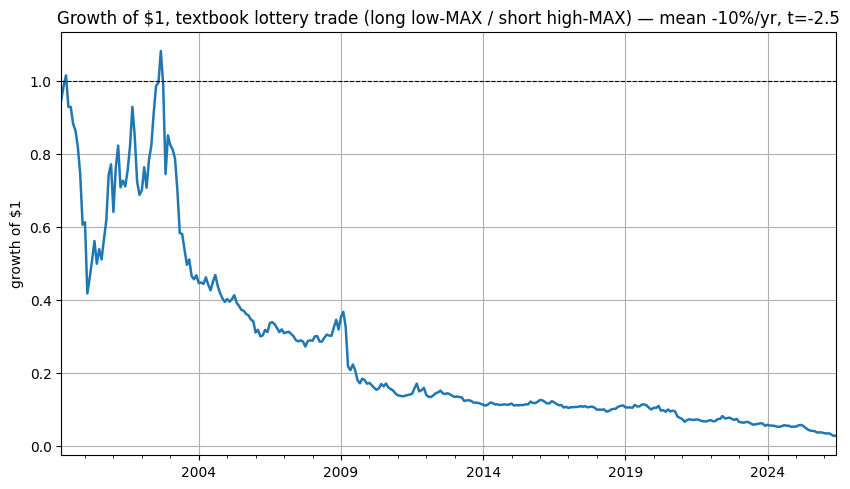

In [2]:
s=st.stats(textbook)
eq=(1+textbook).cumprod()
ax=eq.plot(title=f"Growth of $1, textbook lottery trade (long low-MAX / short high-MAX) — mean {s['mean_ann']:+.0%}/yr, t={s['tstat']:.1f}",lw=1.8)
ax.axhline(1.0,color='k',lw=.8,ls='--'); ax.set_ylabel('growth of $1'); plt.show()

## 4 · The teardown

The line drifts down — shorting the high-MAX names lost money, the opposite of the anomaly. And it got worse in the 2010s growth run.

In [3]:
for lab,sl in [('2000-2012',textbook.loc[:'2012']),('2013-on',textbook.loc['2013':])]:
    print(f'{lab}: Sharpe {st.stats(sl)["sharpe"]:+.2f}, mean {st.stats(sl)["mean_ann"]:+.2%}/yr')

2000-2012: Sharpe -0.40, mean -10.48%/yr
2013-on: Sharpe -0.71, mean -10.28%/yr


**Read it plainly.** On liquid large caps the high-volatility, high-MAX names *won* — the same regime that sank [betting against beta](../../43-free-lunch/). The lottery premium hides in micro-caps; survivorship turns it inside out here.

## 5 · The verdict

**Signal: None** — the trade lost (t −2.5). **Tradability: Mirage** — negative gross, worsening. **Lottery effect on large caps?: Busted.**

## 6 · Could you actually trade it?

Not on liquid stocks — you'd be short the very names that led the market. The documented premium requires the small, illiquid, retail-heavy names (and the delisted blow-ups survivorship hides) — the untradable end.

## 7 · Going further 🚪

MAX is essentially a volatility proxy — see its near-twin [Study 54 Static](../../54-static/) (idiosyncratic volatility), which inverts for the same reason.